# Part 1: Ridge Regression — Overfitting & Regularization
---
In this part, you will:
1. Generate a small noisy dataset from a known function
2. Fit high-degree polynomial features (creating a situation prone to overfitting)
3. Observe overfitting with unregularized regression
4. Apply Ridge (L2) regularization to fix it
5. Find the best regularization parameter

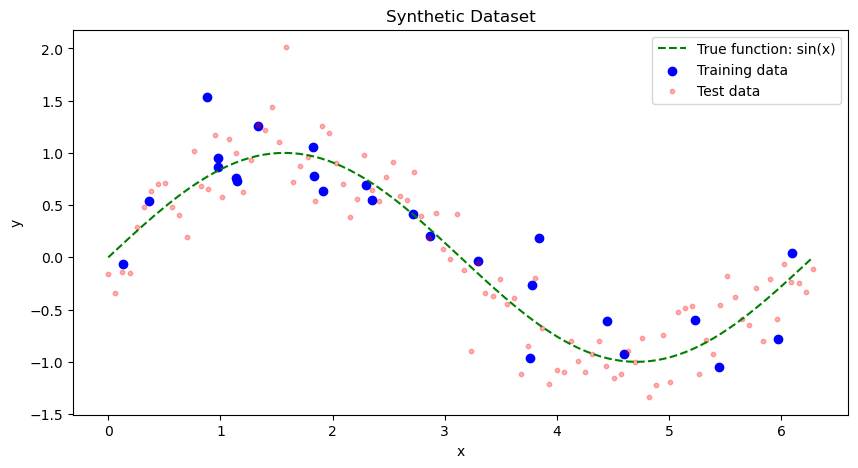

In [1]:
# Step 1: Generate synthetic data from sin(x) + noise
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Generate 25 training points and 100 test points
n_train = 25
n_test = 100

x_train = np.sort(np.random.uniform(0, 2 * np.pi, n_train))
y_train = np.sin(x_train) + 0.3 * np.random.randn(n_train)

x_test = np.linspace(0, 2 * np.pi, n_test)
y_test = np.sin(x_test) + 0.3 * np.random.randn(n_test)

# Plot the training data and the true function
x_true = np.linspace(0, 2 * np.pi, 200)
y_true = np.sin(x_true)

plt.figure(figsize=(10, 5))
plt.plot(x_true, y_true, 'g--', label='True function: sin(x)')
plt.scatter(x_train, y_train, c='blue', label='Training data')
plt.scatter(x_test, y_test, c='red', alpha=0.3, s=10, label='Test data')
plt.legend()
plt.title('Synthetic Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [2]:
# Step 2: Create polynomial features
def polynomial_features(x, degree):
    """Create polynomial feature matrix of shape (n_samples, degree+1)."""
    return np.column_stack([x**i for i in range(degree + 1)])

degree = 15

# Normalize x to [-1, 1] to avoid numerical issues with high-degree polynomials
# (x^15 with x in [0, 2*pi] would reach ~4.7e11, making the matrix ill-conditioned)
x_min, x_max = 0, 2 * np.pi
x_train_norm = 2 * (x_train - x_min) / (x_max - x_min) - 1
x_test_norm = 2 * (x_test - x_min) / (x_max - x_min) - 1
x_true_norm = 2 * (x_true - x_min) / (x_max - x_min) - 1

X_train_poly = polynomial_features(x_train_norm, degree)
X_test_poly = polynomial_features(x_test_norm, degree)
X_true_poly = polynomial_features(x_true_norm, degree)

print(f"Training feature matrix shape: {X_train_poly.shape}")
print(f"We have {X_train_poly.shape[0]} samples and {X_train_poly.shape[1]} features")
print(f"Feature-to-sample ratio: {X_train_poly.shape[1]/X_train_poly.shape[0]:.2f} — close to 1 ⟹ prone to overfitting!")

Training feature matrix shape: (25, 16)
We have 25 samples and 16 features
Feature-to-sample ratio: 0.64 — close to 1 ⟹ prone to overfitting!


### Step 3: Implement evaluation functions and the pseudo-inverse

In [3]:
# Step 3: Implement MSE and the pseudo-inverse
def MSE(prediction, reference):
    """Calculate Mean Squared Error."""
    return np.mean(np.square(prediction - reference))

def pseudo_inverse(A):
    """Calculate the pseudo-inverse of A: (A^T A)^{-1} A^T"""
    return np.matmul(np.linalg.inv(np.matmul(A.T, A)), A.T)

### Step 4: Fit unregularized regression and observe overfitting

Unregularized - Train MSE: 0.0298
Unregularized - Test  MSE: 152.4034
Gap (test - train): 152.3736  <-- large gap = overfitting!


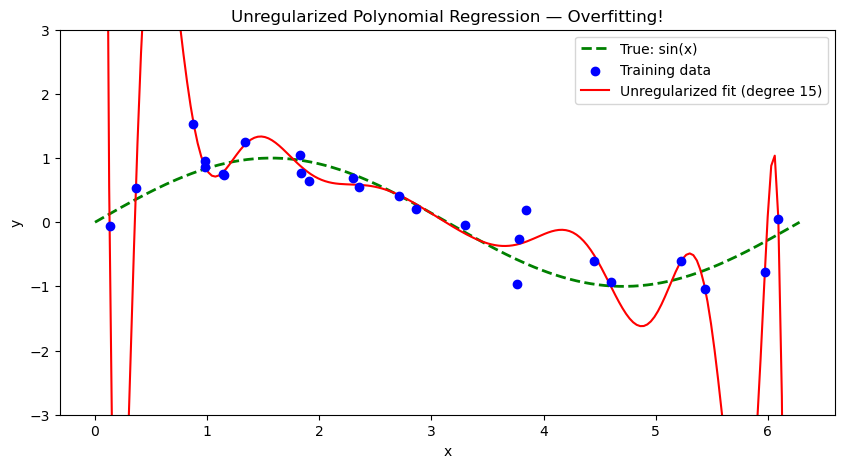

In [4]:
# Step 4: Fit WITHOUT regularization
beta_no_reg = np.matmul(pseudo_inverse(X_train_poly), y_train)

# Predict on training, test, and dense grid
pred_train = np.matmul(X_train_poly, beta_no_reg)
pred_test = np.matmul(X_test_poly, beta_no_reg)
pred_true = np.matmul(X_true_poly, beta_no_reg)

# Calculate MSE
mse_train = MSE(pred_train, y_train)
mse_test = MSE(pred_test, y_test)

print(f"Unregularized - Train MSE: {mse_train:.4f}")
print(f"Unregularized - Test  MSE: {mse_test:.4f}")
print(f"Gap (test - train): {mse_test - mse_train:.4f}  <-- large gap = overfitting!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_true, y_true, 'g--', label='True: sin(x)', linewidth=2)
plt.scatter(x_train, y_train, c='blue', zorder=5, label='Training data')
plt.plot(x_true, pred_true, 'r-', label=f'Unregularized fit (degree {degree})', linewidth=1.5)
plt.ylim(-3, 3)
plt.legend()
plt.title('Unregularized Polynomial Regression — Overfitting!')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Step 5: Implement Ridge (L2) regularized pseudo-inverse

In [5]:
# Step 5: Implement Ridge regularized pseudo-inverse
def regularized_pseudo_inverse(A, lambda_):
    """Calculate the regularized pseudo-inverse: (A^T A + lambda * I)^{-1} A^T"""
    dim = A.shape[1]
    return np.matmul(np.linalg.inv(np.matmul(A.T, A) + lambda_ * np.identity(dim)), A.T)

Ridge (lambda=0.1) - Train MSE: 0.0675
Ridge (lambda=0.1) - Test  MSE: 0.1665
Gap: 0.0990


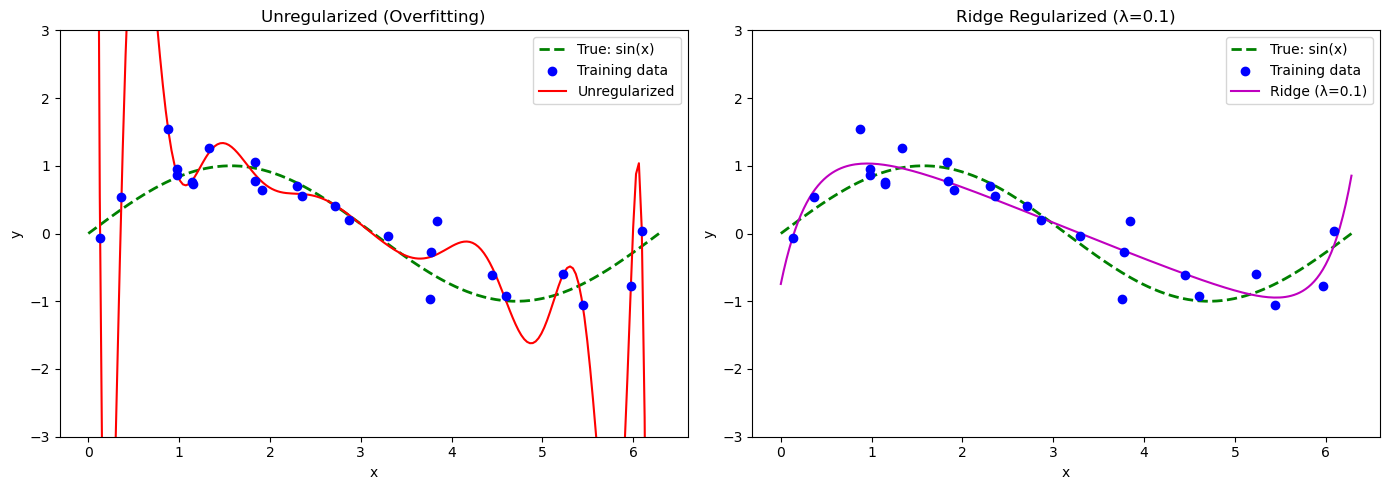

In [6]:
# Step 6: Fit WITH Ridge regularization and compare
lambda_ = 0.1

beta_ridge = np.matmul(regularized_pseudo_inverse(X_train_poly, lambda_), y_train)

# Predict
pred_train_ridge = np.matmul(X_train_poly, beta_ridge)
pred_test_ridge = np.matmul(X_test_poly, beta_ridge)
pred_true_ridge = np.matmul(X_true_poly, beta_ridge)

mse_train_ridge = MSE(pred_train_ridge, y_train)
mse_test_ridge = MSE(pred_test_ridge, y_test)

print(f"Ridge (lambda={lambda_}) - Train MSE: {mse_train_ridge:.4f}")
print(f"Ridge (lambda={lambda_}) - Test  MSE: {mse_test_ridge:.4f}")
print(f"Gap: {mse_test_ridge - mse_train_ridge:.4f}")

# Plot both fits side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_true, y_true, 'g--', linewidth=2, label='True: sin(x)')
axes[0].scatter(x_train, y_train, c='blue', zorder=5, label='Training data')
axes[0].plot(x_true, pred_true, 'r-', linewidth=1.5, label='Unregularized')
axes[0].set_ylim(-3, 3)
axes[0].set_title('Unregularized (Overfitting)')
axes[0].legend()
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].plot(x_true, y_true, 'g--', linewidth=2, label='True: sin(x)')
axes[1].scatter(x_train, y_train, c='blue', zorder=5, label='Training data')
axes[1].plot(x_true, pred_true_ridge, 'm-', linewidth=1.5, label=f'Ridge (λ={lambda_})')
axes[1].set_ylim(-3, 3)
axes[1].set_title(f'Ridge Regularized (λ={lambda_})')
axes[1].legend()
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

### Step 7: Find the best λ — Train vs Test MSE curve

Best lambda: 0.065793
Best test MSE: 0.1659


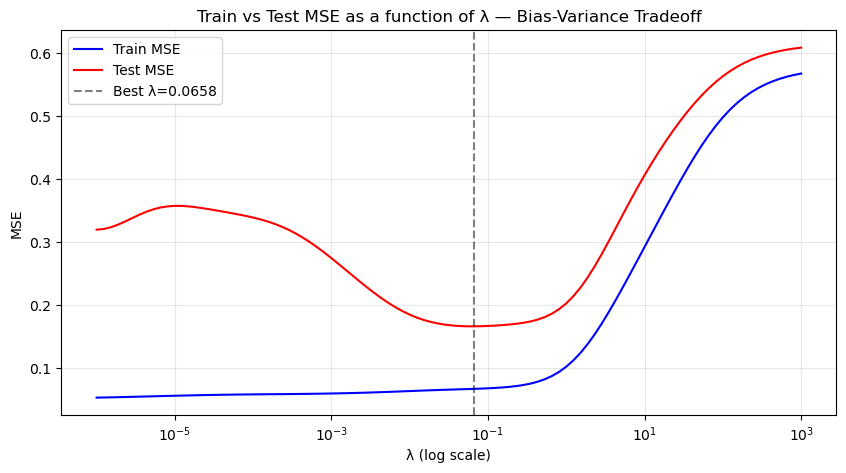

In [7]:
# Step 7: Sweep lambda values and plot train vs test MSE
lambdas = np.logspace(-6, 3, 100)

mse_train_list = np.zeros(len(lambdas))
mse_test_list = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    beta = np.matmul(regularized_pseudo_inverse(X_train_poly, lam), y_train)
    
    pred_tr = np.matmul(X_train_poly, beta)
    pred_te = np.matmul(X_test_poly, beta)
    
    mse_train_list[i] = MSE(pred_tr, y_train)
    mse_test_list[i] = MSE(pred_te, y_test)

# Find best lambda
best_idx = np.argmin(mse_test_list)
best_lambda = lambdas[best_idx]
print(f"Best lambda: {best_lambda:.6f}")
print(f"Best test MSE: {mse_test_list[best_idx]:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(lambdas, mse_train_list, 'b-', label='Train MSE')
plt.semilogx(lambdas, mse_test_list, 'r-', label='Test MSE')
plt.axvline(x=best_lambda, color='k', linestyle='--', alpha=0.5, label=f'Best λ={best_lambda:.4f}')
plt.xlabel('λ (log scale)')
plt.ylabel('MSE')
plt.title('Train vs Test MSE as a function of λ — Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

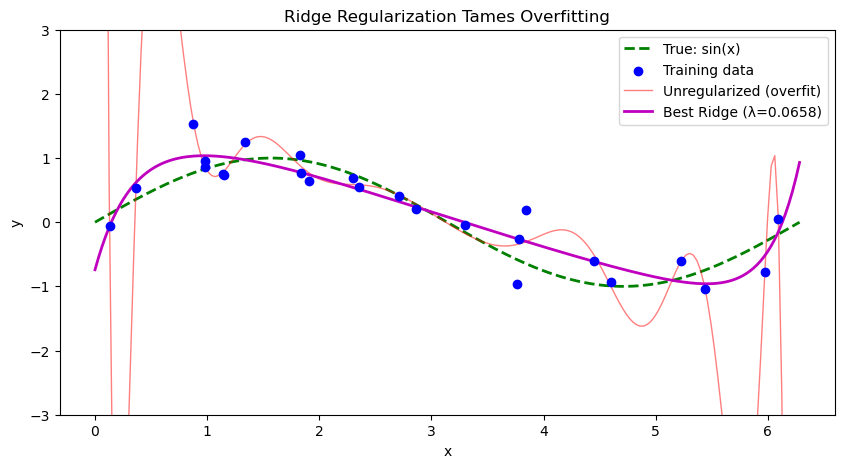

In [8]:
# Step 8: Final comparison - plot the best Ridge fit
beta_best = np.matmul(regularized_pseudo_inverse(X_train_poly, best_lambda), y_train)
pred_true_best = np.matmul(X_true_poly, beta_best)

plt.figure(figsize=(10, 5))
plt.plot(x_true, y_true, 'g--', linewidth=2, label='True: sin(x)')
plt.scatter(x_train, y_train, c='blue', zorder=5, label='Training data')
plt.plot(x_true, pred_true, 'r-', alpha=0.5, linewidth=1, label='Unregularized (overfit)')
plt.plot(x_true, pred_true_best, 'm-', linewidth=2, label=f'Best Ridge (λ={best_lambda:.4f})')
plt.ylim(-3, 3)
plt.legend()
plt.title('Ridge Regularization Tames Overfitting')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Part 2: Lasso Regression — Sparsity & Feature Selection
---
In this part, you will:
1. Generate a high-dimensional dataset where only a few features matter
2. Observe that unregularized regression overfits (and uses ALL features)
3. Apply Lasso (L1) to automatically select the important features
4. Compare Ridge vs Lasso to understand L2 vs L1 regularization

In [9]:
# Step 1: Generate a sparse high-dimensional synthetic dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
np.random.seed(42)

n_samples = 80
n_features = 50
n_informative = 5  # only 5 features actually matter!

# Generate random features
X = np.random.randn(n_samples, n_features)

# The TRUE coefficients: only 5 are non-zero
true_coefs = np.zeros(n_features)
true_coefs[0] = 3.0
true_coefs[5] = -2.0
true_coefs[10] = 1.5
true_coefs[20] = -4.0
true_coefs[35] = 2.5

# Generate target with noise
y = X @ true_coefs + 0.5 * np.random.randn(n_samples)

# Split: small training set to encourage overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"True non-zero coefficients at indices: {np.where(true_coefs != 0)[0]}")
print(f"True coefficient values: {true_coefs[true_coefs != 0]}")

Training set: 48 samples, 50 features
Test set: 32 samples, 50 features
True non-zero coefficients at indices: [ 0  5 10 20 35]
True coefficient values: [ 3.  -2.   1.5 -4.   2.5]


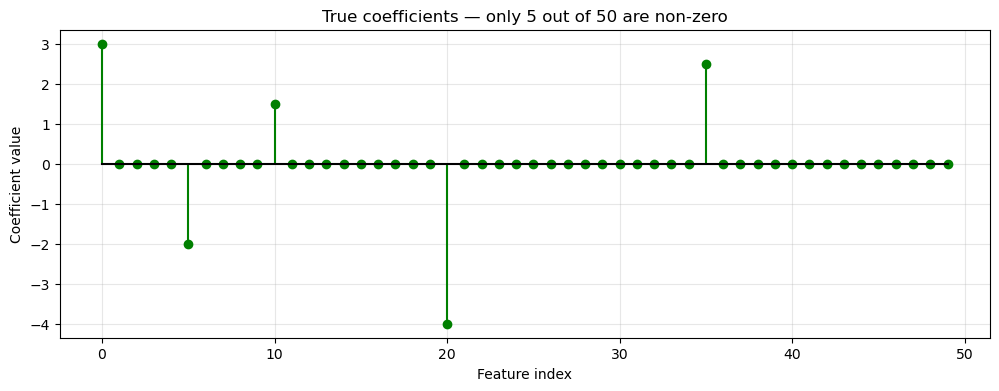

In [10]:
# Step 2: Visualize the true coefficients
plt.figure(figsize=(12, 4))
plt.stem(range(n_features), true_coefs, linefmt='g-', markerfmt='go', basefmt='k-')
plt.xlabel('Feature index')
plt.ylabel('Coefficient value')
plt.title(f'True coefficients — only {n_informative} out of {n_features} are non-zero')
plt.grid(True, alpha=0.3)
plt.show()

### Step 3: Fit unregularized linear regression

In [11]:
# Step 3: Unregularized linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

linear = LinearRegression()
linear.fit(X_train, y_train)

y_pred_train_lin = linear.predict(X_train)
y_pred_test_lin = linear.predict(X_test)

mse_train_lin = mean_squared_error(y_train, y_pred_train_lin)
mse_test_lin = mean_squared_error(y_test, y_pred_test_lin)

print(f"Linear Regression - Train MSE: {mse_train_lin:.4f}")
print(f"Linear Regression - Test  MSE: {mse_test_lin:.4f}")
print(f"Gap: {mse_test_lin - mse_train_lin:.4f}  <-- overfitting!")
print(f"Number of non-zero coefficients: {np.sum(np.abs(linear.coef_) > 0.01)}/{n_features}")

Linear Regression - Train MSE: 0.0000
Linear Regression - Test  MSE: 4.7898
Gap: 4.7898  <-- overfitting!
Number of non-zero coefficients: 50/50


### Step 4: Fit Lasso (L1 regularization)

In [12]:
# Step 4: Lasso regression 
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_train_lasso = lasso.predict(X_train)
y_pred_test_lasso = lasso.predict(X_test)

mse_train_lasso = mean_squared_error(y_train, y_pred_train_lasso)
mse_test_lasso = mean_squared_error(y_test, y_pred_test_lasso)

print(f"Lasso (alpha=0.1) - Train MSE: {mse_train_lasso:.4f}")
print(f"Lasso (alpha=0.1) - Test  MSE: {mse_test_lasso:.4f}")
print(f"Gap: {mse_test_lasso - mse_train_lasso:.4f}")
print(f"Number of non-zero coefficients: {np.sum(np.abs(lasso.coef_) > 0.01)}/{n_features}")

Lasso (alpha=0.1) - Train MSE: 0.2024
Lasso (alpha=0.1) - Test  MSE: 0.5130
Gap: 0.3106
Number of non-zero coefficients: 7/50


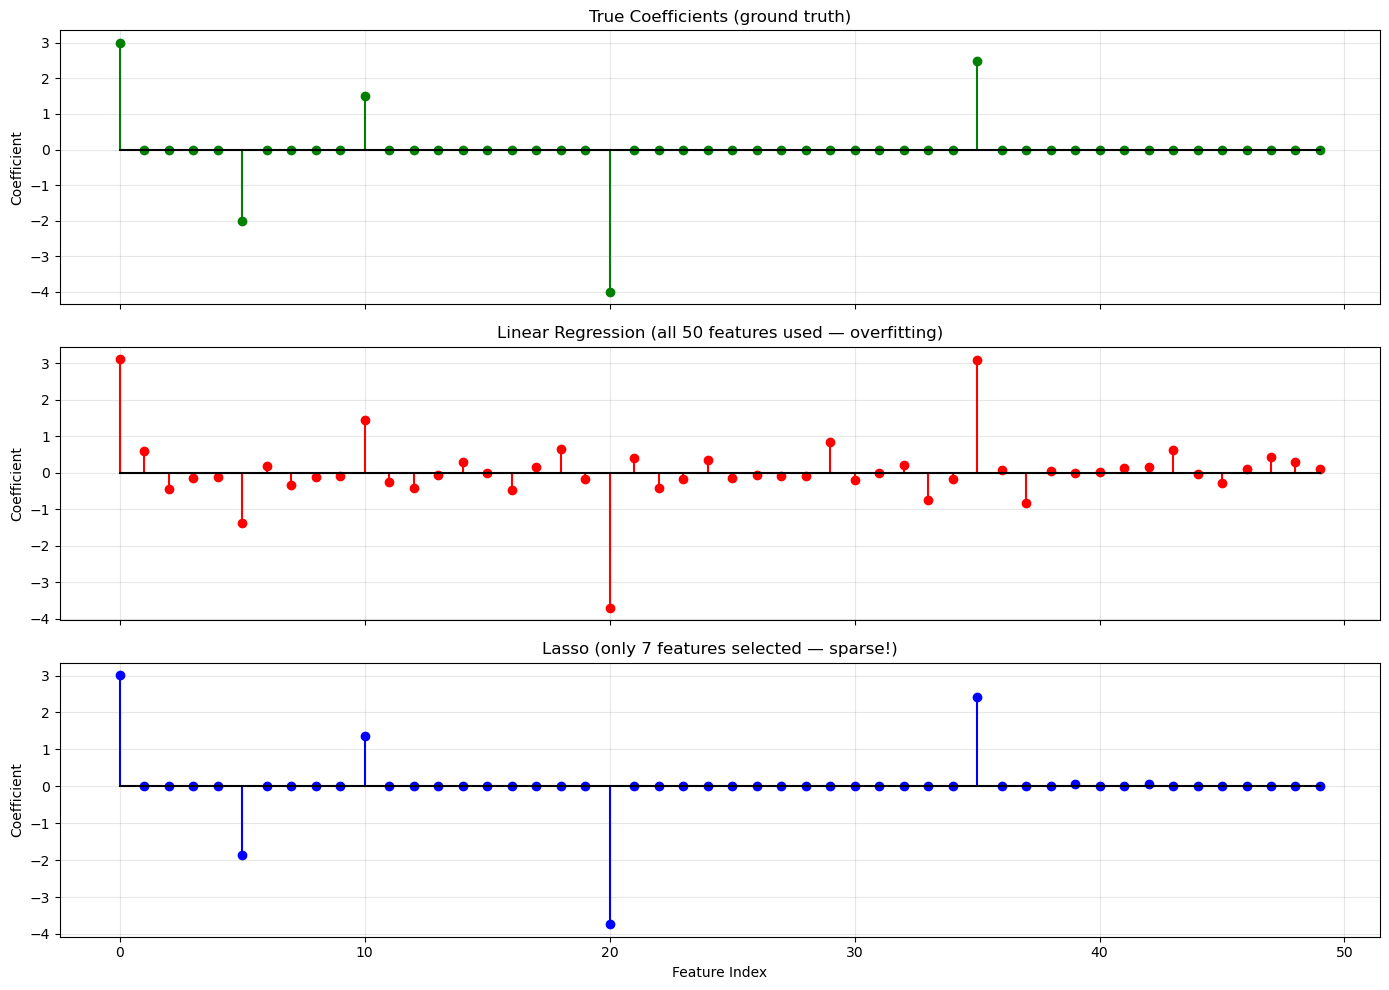

In [13]:
# Step 5: Compare learned coefficients — Linear vs Lasso vs Truth
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].stem(range(n_features), true_coefs, linefmt='g-', markerfmt='go', basefmt='k-')
axes[0].set_ylabel('Coefficient')
axes[0].set_title('True Coefficients (ground truth)')
axes[0].grid(True, alpha=0.3)

axes[1].stem(range(n_features), linear.coef_, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_ylabel('Coefficient')
axes[1].set_title(f'Linear Regression (all {np.sum(np.abs(linear.coef_) > 0.01)} features used — overfitting)')
axes[1].grid(True, alpha=0.3)

axes[2].stem(range(n_features), lasso.coef_, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[2].set_ylabel('Coefficient')
axes[2].set_title(f'Lasso (only {np.sum(np.abs(lasso.coef_) > 0.01)} features selected — sparse!)')
axes[2].set_xlabel('Feature Index')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 6: Compare Lasso vs Ridge to understand L1 vs L2

In [14]:
# Step 6: Ridge vs Lasso comparison
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_test_ridge = ridge.predict(X_test)
mse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge)

print(f"Test MSE comparison:")
print(f"  Linear (no reg):    {mse_test_lin:.4f}")
print(f"  Ridge  (alpha=0.1): {mse_test_ridge:.4f}")
print(f"  Lasso  (alpha=0.1): {mse_test_lasso:.4f}")
print()
print(f"Non-zero coefficients:")
print(f"  True:   {np.sum(np.abs(true_coefs) > 0.01)}")
print(f"  Linear: {np.sum(np.abs(linear.coef_) > 0.01)}")
print(f"  Ridge:  {np.sum(np.abs(ridge.coef_) > 0.01)}  (shrunk but NOT zero)")
print(f"  Lasso:  {np.sum(np.abs(lasso.coef_) > 0.01)}  (sparse!)")

Test MSE comparison:
  Linear (no reg):    4.7898
  Ridge  (alpha=0.1): 3.6417
  Lasso  (alpha=0.1): 0.5130

Non-zero coefficients:
  True:   5
  Linear: 50
  Ridge:  48  (shrunk but NOT zero)
  Lasso:  7  (sparse!)


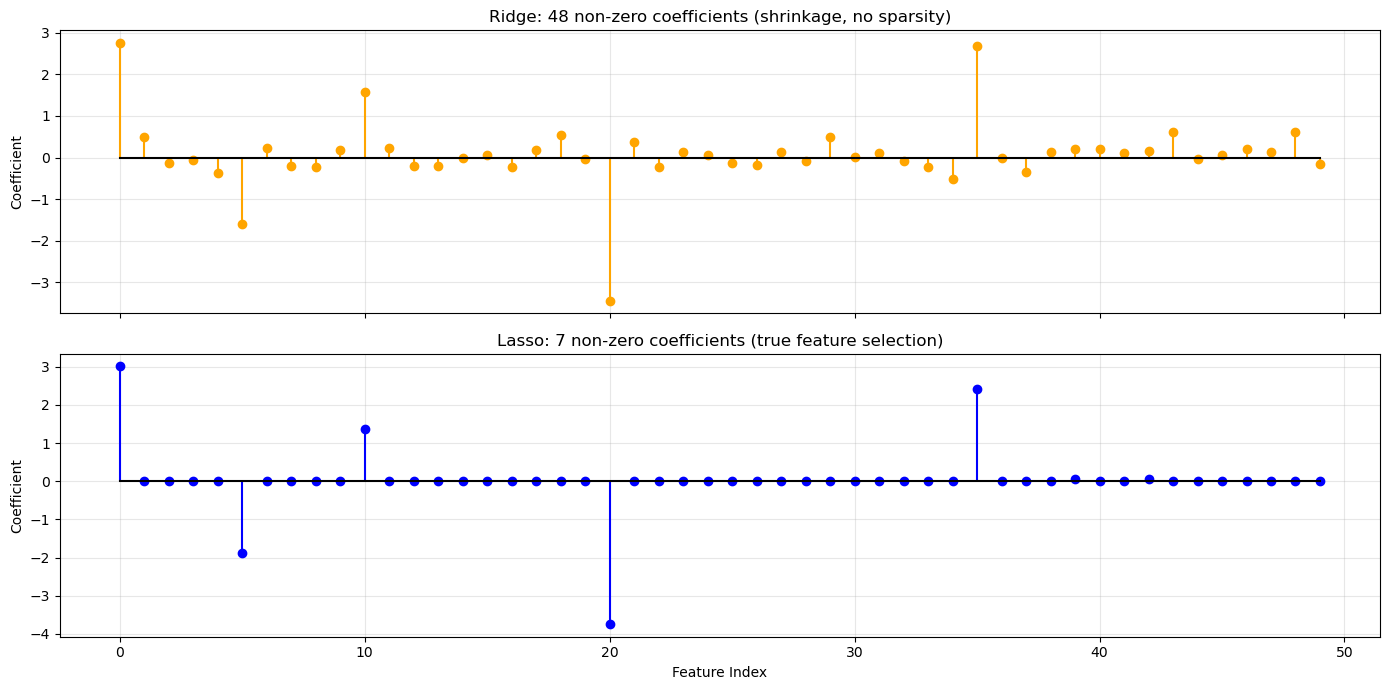

In [15]:
# Visualize Ridge vs Lasso coefficients
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].stem(range(n_features), ridge.coef_, linefmt='orange', markerfmt='o', basefmt='k-')
axes[0].set_ylabel('Coefficient')
axes[0].set_title(f'Ridge: {np.sum(np.abs(ridge.coef_) > 0.01)} non-zero coefficients (shrinkage, no sparsity)')
axes[0].grid(True, alpha=0.3)

axes[1].stem(range(n_features), lasso.coef_, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[1].set_ylabel('Coefficient')
axes[1].set_title(f'Lasso: {np.sum(np.abs(lasso.coef_) > 0.01)} non-zero coefficients (true feature selection)')
axes[1].set_xlabel('Feature Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 7: Find the best alpha for Lasso

Best alpha: 0.0754
Best test MSE: 0.4670
Features selected at best alpha: 9


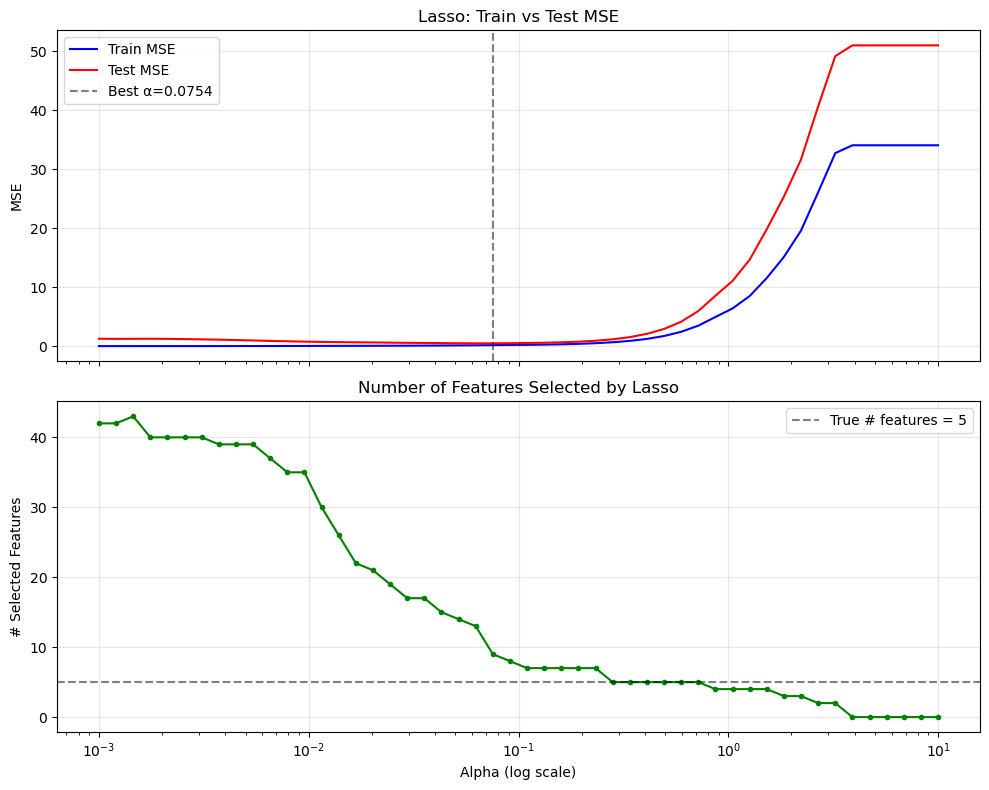

In [16]:
# Step 7: Sweep alpha values for Lasso
alpha_list = np.logspace(-3, 1, 50)
mse_train_list = np.zeros(len(alpha_list))
mse_test_list = np.zeros(len(alpha_list))
n_selected = np.zeros(len(alpha_list))

for i, alpha in enumerate(alpha_list):
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)
    
    mse_train_list[i] = mean_squared_error(y_train, model.predict(X_train))
    mse_test_list[i] = mean_squared_error(y_test, model.predict(X_test))
    n_selected[i] = np.sum(np.abs(model.coef_) > 0.01)

best_idx = np.argmin(mse_test_list)
print(f"Best alpha: {alpha_list[best_idx]:.4f}")
print(f"Best test MSE: {mse_test_list[best_idx]:.4f}")
print(f"Features selected at best alpha: {int(n_selected[best_idx])}")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.semilogx(alpha_list, mse_train_list, 'b-', label='Train MSE')
ax1.semilogx(alpha_list, mse_test_list, 'r-', label='Test MSE')
ax1.axvline(x=alpha_list[best_idx], color='k', linestyle='--', alpha=0.5, label=f'Best α={alpha_list[best_idx]:.4f}')
ax1.set_ylabel('MSE')
ax1.set_title('Lasso: Train vs Test MSE')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.semilogx(alpha_list, n_selected, 'g-o', markersize=3)
ax2.axhline(y=n_informative, color='k', linestyle='--', alpha=0.5, label=f'True # features = {n_informative}')
ax2.set_xlabel('Alpha (log scale)')
ax2.set_ylabel('# Selected Features')
ax2.set_title('Number of Features Selected by Lasso')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()